# Miku Stomp digital — replicar el pedal Korg en DSP puro

**Procesamiento Digital de Señales e Imágenes (INFB6063) — UTEM 2026-1**
Francisco Alejandro Pinto Abraham · RUT 21.571.239-7

El pedal **Korg Miku Stomp** convierte lo que tocas en una "voz de Hatsune Miku". Aquí lo replicamos
en Python con el mismo flujo —**audio de guitarra → detectar la nota → afinar una voz a esa nota →
audio de salida**— pero **mejor que el pedal**: el pedal mueve los *formantes* al cambiar el tono
(efecto "ardilla"); nosotros usamos un **phase vocoder con preservación de formantes** (de nuestro
proyecto del artículo de Dolson 1986), así la voz mantiene su timbre al seguir la melodía.

**Regla del ramo:** todo es DSP clásico — detección de tono **pYIN** (YIN probabilístico, *no* es una
red neuronal), **STFT**, **phase vocoder**, **formantes por cepstrum**, **overlap-add** y **mezcla**.
Sin deep learning / IA generativa (RVC, Basic Pitch, etc. quedan solo como *trabajo futuro*).

> En Colab: **Entorno de ejecución → Ejecutar todo**. Trae **incluida una voz real de Vocaloid 4**
> (CyberDiva), así que suena a voz de verdad sin subir nada. Puedes subir tu propia guitarra y/o tu
> propia voz si quieres; si no, usa una guitarra de ejemplo y la voz incluida, y corre de principio a fin.


## 0. Dependencias

In [1]:
# En Colab instala lo necesario; local: si ya está, no hace nada.
try:
    import google.colab  # noqa
    !pip install -q librosa soundfile numpy scipy matplotlib
except Exception:
    pass
print("Dependencias listas.")


Dependencias listas.


In [2]:
import os, io, urllib.request, warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
warnings.filterwarnings("ignore")
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("IN_COLAB =", IN_COLAB)


IN_COLAB = False


## 1. Núcleo DSP (phase vocoder + formantes)
Mismas funciones validadas en `vocoder.py` (Dolson 1986 + extensión de formantes).

In [3]:
# -*- coding: utf-8 -*-
"""
vocoder.py -- Núcleo DSP del proyecto "Phase Vocoder (Dolson 1986) + Pedal Miku".

Procesamiento Digital de Señales e Imágenes (INFB6063) -- UTEM 2026-1
Estudiante: Francisco Alejandro Pinto Abraham -- RUT 21.571.239-7

Contiene:
  1) Utilidades de señal y análisis de Fourier REUTILIZADAS del proyecto previo
     `miku_pedal.ipynb` (declaradas explícitamente como código reutilizado).
  2) La REPRODUCCIÓN del phase vocoder de Dolson (STFT -> frecuencia instantánea por
     fase -> time-stretch -> pitch-shift).
  3) La EXTENSIÓN propia: phase vocoder con preservación de formantes (corrección de
     envolvente espectral por cepstrum).
  4) Tres métodos de pitch-shift comparables: remuestreo ingenuo (baseline),
     phase vocoder, y phase vocoder + formantes.
  5) Métricas de evaluación (error de f0 en cents, error de duración, centroide de la
     envolvente, distancia log-espectral).

Todo es DSP clásico del curso: DFT/FFT, STFT, enventanado Hann, fase, cepstrum,
overlap-add, muestreo/interpolación. Sin ML / deep learning / LLM.
"""

import os
import numpy as np

SR = 22050                       # frecuencia de muestreo de trabajo (Hz)
EPS = 1e-9

# Mapa vocal -> formantes (fc, ancho de banda, ganancia). Reutilizado de miku_pedal.ipynb.
VOWEL_FORMANTS = {
    'a': ((800.0, 90.0, 1.00), (1150.0, 110.0, 0.82), (2900.0, 240.0, 0.38)),
    'e': ((500.0, 80.0, 0.95), (1750.0, 150.0, 0.88), (2450.0, 220.0, 0.34)),
    'i': ((320.0, 70.0, 0.92), (2200.0, 170.0, 0.95), (3000.0, 260.0, 0.42)),
    'o': ((500.0, 80.0, 0.96), (900.0, 110.0, 0.82), (2600.0, 240.0, 0.32)),
    'u': ((350.0, 70.0, 0.96), (800.0, 100.0, 0.78), (2200.0, 230.0, 0.28)),
}


# =====================================================================================
# 1) UTILIDADES REUTILIZADAS de miku_pedal.ipynb  (declaradas como código reutilizado)
# =====================================================================================
def ensure_mono_float(audio):
    """Fuerza la señal a mono float32 y limpia NaN/Inf. [Reutilizado de miku_pedal.ipynb]"""
    a = np.asarray(audio, dtype=np.float32)
    if a.ndim > 1:
        a = np.mean(a, axis=-1)
    return np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0).flatten().astype(np.float32)


def normalize_audio(audio, peak=0.95, eps=EPS):
    """Escala la señal para que su pico no supere 'peak'. [Reutilizado de miku_pedal.ipynb]"""
    a = ensure_mono_float(audio)
    if a.size == 0:
        return a
    m = float(np.max(np.abs(a)))
    return a.copy() if m < eps else (a / m * peak).astype(np.float32)


def apply_short_fade(audio, fade=64):
    """Fade-in/out lineal para unir granos sin clicks. [Reutilizado de miku_pedal.ipynb]"""
    a = ensure_mono_float(audio)
    f = int(min(max(fade, 0), a.size // 2))
    if f <= 1:
        return a
    ramp = np.linspace(0.0, 1.0, f, dtype=np.float32)
    a[:f] *= ramp
    a[-f:] *= ramp[::-1]
    return a


def compute_rfft(x, fs=SR):
    """DFT de señal real: devuelve frecuencias (Hz) y magnitud. [Reutilizado de miku_pedal.ipynb]"""
    x = ensure_mono_float(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0 / fs)
    return f, np.abs(X)


def spectrum_peaks_valleys(x, fs=SR, n_peaks=6, fmin=70.0, fmax=2000.0):
    """Máximos (picos) y mínimos (valles) locales del espectro. [Reutilizado de miku_pedal.ipynb]"""
    f, mag = compute_rfft(x, fs)
    band = (f >= fmin) & (f <= fmax)
    fb, mb = f[band], mag[band]
    peaks = [i for i in range(1, len(mb) - 1) if mb[i] > mb[i - 1] and mb[i] >= mb[i + 1]]
    valleys = [i for i in range(1, len(mb) - 1) if mb[i] < mb[i - 1] and mb[i] <= mb[i + 1]]
    top = sorted(sorted(peaks, key=lambda i: -mb[i])[:n_peaks])
    return fb, mb, np.array(top, dtype=int), np.array(valleys, dtype=int)


def apply_formants(src, sr, vowel):
    """Color de vocal por máscara de formantes en frecuencia. [Reutilizado de miku_pedal.ipynb]"""
    src = ensure_mono_float(src)
    n = len(src)
    if n < 4:
        return src
    spec = np.fft.rfft(src)
    freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    H = np.full_like(freqs, 0.05, dtype=np.float64)
    for fc, bw, g in VOWEL_FORMANTS.get(vowel, VOWEL_FORMANTS['a']):
        H += g * np.exp(-0.5 * ((freqs - fc) / max(bw, 1.0)) ** 2)
    return np.fft.irfft(spec * H, n=n).astype(np.float32)


def build_guitar_unit_db(x, sr, unit_ms=140, hop_ms=70, fmin=70.0, fmax=1000.0, gate=0.12):
    """Base de 'difonos': granos de guitarra enventanados con f0 y energía. [Reutilizado]"""
    x = ensure_mono_float(x)
    L = max(64, int(unit_ms / 1000.0 * sr))
    H = max(1, int(hop_ms / 1000.0 * sr))
    win = np.hanning(L).astype(np.float32)
    freqs = np.fft.rfftfreq(L, d=1.0 / sr)
    band = (freqs >= fmin) & (freqs <= fmax)
    grains = [(s, x[s:s + L] * win) for s in range(0, len(x) - L, H)]
    if not grains:
        return []
    energies = [float(np.sqrt(np.mean(g ** 2))) for _, g in grains]
    thr = max(energies) * float(gate)
    db = []
    for (s, g), e in zip(grains, energies):
        if e < thr:
            continue
        mag = np.abs(np.fft.rfft(g))
        mb = np.where(band, mag, 0.0)
        db.append({'wave': g.astype(np.float32), 'f0': float(freqs[int(np.argmax(mb))]), 'energy': e})
    return db


def track_dominant_per_frame(x, fs=SR, frame=2048, hop=1024, fmin=70.0, fmax=2000.0):
    """Frecuencia dominante y energía por tramo (STFT). [Reutilizado de miku_pedal.ipynb]"""
    x = ensure_mono_float(x)
    if len(x) < frame:
        x = np.pad(x, (0, frame - len(x)))
    win = np.hanning(frame).astype(np.float32)
    freqs = np.fft.rfftfreq(frame, d=1.0 / fs)
    band = (freqs >= fmin) & (freqs <= fmax)
    times, f0, energy = [], [], []
    for s in range(0, len(x) - frame + 1, hop):
        fr = x[s:s + frame] * win
        mag = np.abs(np.fft.rfft(fr))
        mb = np.where(band, mag, 0.0)
        f0.append(float(freqs[int(np.argmax(mb))]))
        energy.append(float(np.sqrt(np.mean(fr ** 2))))
        times.append((s + frame / 2) / fs)
    return np.array(times), np.array(f0), np.array(energy)


def select_unit(db, f_target):
    """Selecciona el difono de f0 más cercana al objetivo. [Reutilizado de miku_pedal.ipynb]"""
    return min(db, key=lambda u: abs(u['f0'] - f_target))


def mix_over(dry, wet, mix=0.6):
    """Mezcla guitarra seca + voz concatenativa. [Reutilizado de miku_pedal.ipynb]"""
    dry = ensure_mono_float(dry)
    wet = ensure_mono_float(wet)
    L = max(len(dry), len(wet))
    d = np.zeros(L, dtype=np.float32); d[:len(dry)] = dry
    w = np.zeros(L, dtype=np.float32); w[:len(wet)] = wet
    return normalize_audio((1.0 - mix) * d + mix * w)


# =====================================================================================
# 2) STFT / ISTFT  (núcleo de análisis-síntesis, materia del curso: U2-L1)
# =====================================================================================
def stft(x, n_fft=1024, hop=256, win=None):
    """Qué hace: Transformada de Fourier de Tiempo Corto.
    Curso: Unit 2 - Lecture 1 (STFT/enventanado), Unit 1 - L3 (DFT).
    Matemática: X[m,k] = sum_n x[n + m*hop] w[n] e^{-j 2π k n / Nfft}. Devuelve (frames, bins).
    """
    x = ensure_mono_float(x)
    if win is None:
        win = np.hanning(n_fft).astype(np.float32)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))
    n_frames = 1 + (len(x) - n_fft) // hop
    cols = []
    for m in range(n_frames):
        s = m * hop
        cols.append(np.fft.rfft(x[s:s + n_fft] * win))
    return np.array(cols)


def istft(X, n_fft=1024, hop=256, win=None, length=None):
    """Qué hace: reconstrucción por superposición-suma (overlap-add) con normalización de ventana.
    Curso: Unit 2 - Lecture 1/2 (enventanado y superposición).
    Matemática: x[n] = sum_m (IDFT(X[m]) w[n]) / sum_m w[n]^2  (OLA con ventana al cuadrado).
    """
    if win is None:
        win = np.hanning(n_fft).astype(np.float32)
    n_frames = X.shape[0]
    out_len = n_fft + hop * (n_frames - 1)
    y = np.zeros(out_len, dtype=np.float64)
    wsum = np.zeros(out_len, dtype=np.float64)
    for m in range(n_frames):
        frame = np.fft.irfft(X[m], n=n_fft)
        s = m * hop
        y[s:s + n_fft] += frame * win
        wsum[s:s + n_fft] += win ** 2
    y = y / np.where(wsum > EPS, wsum, 1.0)
    if length is not None:
        y = y[:length] if len(y) >= length else np.pad(y, (0, length - len(y)))
    return y.astype(np.float32)


# =====================================================================================
# 3) PHASE VOCODER  (REPRODUCCIÓN de Dolson 1986)
# =====================================================================================
def phase_vocoder(X, stretch, hop, n_fft):
    """Qué hace: estira/comprime en el tiempo una STFT preservando la frecuencia, propagando la fase
    por la FRECUENCIA INSTANTÁNEA (corazón del phase vocoder de Dolson 1986).
    Curso: Unit 2 - L1 (STFT), Unit 1 - L2/3 (fase de la DFT), enventanado.
    Matemática: para cada bin k, la fase esperada por salto es Δφ_esp = 2π·hop·k/Nfft. La desviación
    medida Δφ - Δφ_esp se envuelve a (-π,π] (heterodinaje) y da la frecuencia instantánea; la fase de
    síntesis se acumula con ese incremento. La magnitud se interpola linealmente entre tramas.

    stretch > 1 -> salida más larga (más lenta);  stretch < 1 -> más corta (más rápida).
    """
    n_frames, n_bins = X.shape
    omega = 2.0 * np.pi * hop * np.arange(n_bins) / n_fft       # avance de fase esperado por bin
    Xpad = np.vstack([X, np.zeros((1, n_bins), dtype=X.dtype)])  # tramo extra para interpolar
    steps = np.arange(0, n_frames, 1.0 / stretch)               # posiciones de análisis (fraccionarias)
    out = np.zeros((len(steps), n_bins), dtype=np.complex128)
    phase_acc = np.angle(Xpad[0])
    for i, step in enumerate(steps):
        f0 = int(np.floor(step))
        frac = step - f0
        mag = (1.0 - frac) * np.abs(Xpad[f0]) + frac * np.abs(Xpad[f0 + 1])
        out[i] = mag * np.exp(1j * phase_acc)
        dphase = np.angle(Xpad[f0 + 1]) - np.angle(Xpad[f0]) - omega
        dphase = dphase - 2.0 * np.pi * np.round(dphase / (2.0 * np.pi))   # envolver a (-π,π]
        phase_acc = phase_acc + omega + dphase
    return out


def time_stretch_pv(x, stretch, n_fft=1024, hop=256):
    """Qué hace: cambia la DURACIÓN sin cambiar el tono, vía phase vocoder.
    Curso: Unit 2 - L1 (STFT/OLA), Dolson 1986. stretch>1 = más largo.
    """
    x = ensure_mono_float(x)
    if x.size < n_fft:
        x = np.pad(x, (0, n_fft - x.size))
    win = np.hanning(n_fft).astype(np.float32)
    X = stft(x, n_fft=n_fft, hop=hop, win=win)
    Xs = phase_vocoder(X, stretch, hop=hop, n_fft=n_fft)
    target = int(round(len(x) * stretch))
    return istft(Xs, n_fft=n_fft, hop=hop, win=win, length=target)


def _resample_linear(x, n_out):
    """Remuestreo por interpolación lineal a 'n_out' muestras (muestreo, U1-L3)."""
    x = ensure_mono_float(x)
    if x.size < 2 or n_out < 2:
        return x
    idx = np.linspace(0.0, x.size - 1, int(n_out))
    return np.interp(idx, np.arange(x.size), x).astype(np.float32)


def pitch_shift_pv(x, n_semitones, n_fft=1024, hop=256):
    """Qué hace: PITCH-SHIFT preservando la DURACIÓN (método de Dolson): time-stretch + remuestreo.
    Curso: Dolson 1986; Unit 2 - L1 (STFT), Unit 1 - L3 (remuestreo).
    Matemática: ratio = 2^(n/12). Se estira el tiempo por 'ratio' (queda más largo) y luego se
    remuestrea de vuelta a la longitud original -> los armónicos suben por 'ratio' y la duración se conserva.
    """
    x = ensure_mono_float(x)
    ratio = 2.0 ** (float(n_semitones) / 12.0)
    if abs(n_semitones) < 1e-6 or x.size < n_fft:
        return x
    stretched = time_stretch_pv(x, ratio, n_fft=n_fft, hop=hop)
    return _resample_linear(stretched, len(x))


def pitch_shift_resample(x, n_semitones):
    """Qué hace: PITCH-SHIFT por REMUESTREO ingenuo (BASELINE = el pitch_fit original de Miku).
    Curso: Unit 1 - L3 (muestreo/interpolación). [Equivalente al pitch_fit de miku_pedal.ipynb]
    Matemática: leer la señal a paso 'ratio' = 2^(n/12). CAMBIA la duración y CORRE los formantes.
    """
    x = ensure_mono_float(x)
    ratio = 2.0 ** (float(n_semitones) / 12.0)
    if abs(n_semitones) < 1e-6 or x.size < 4:
        return x
    pos = np.arange(0, len(x), ratio)
    if pos.size < 4:
        return x
    return np.interp(pos, np.arange(len(x)), x).astype(np.float32)


# =====================================================================================
# 4) EXTENSIÓN PROPIA: preservación de formantes por envolvente cepstral
# =====================================================================================
def cepstral_envelope(mag, n_lifter=30):
    """Qué hace: estima la ENVOLVENTE espectral (formantes) suavizando el log-espectro con un lifter cepstral.
    Curso: Unit 1 - L2/3 (DFT/IDFT) + filtrado en cuefrencia (cepstrum).
    Matemática: env = exp( low-quefrency( IDFT( log|S| ) ) ). Las cuefrencias altas (estructura fina
    armónica) se ponen a cero; quedan solo los formantes.
    """
    mag = np.asarray(mag, dtype=np.float64)
    log_mag = np.log(mag + EPS)
    cep = np.fft.irfft(log_mag)                  # cepstro real, longitud 2*(bins-1)
    n = cep.size
    k = int(min(max(n_lifter, 1), n // 2 - 1))
    lifter = np.zeros(n)
    lifter[:k] = 1.0
    lifter[-k + 1:] = 1.0 if k > 1 else 0.0      # mantener simetría de cuefrencias bajas
    env = np.exp(np.fft.rfft(cep * lifter).real)
    return env[:mag.size]


def pitch_shift_pv_formant(x, n_semitones, n_fft=1024, hop=256, n_lifter=30):
    """Qué hace: phase vocoder con PRESERVACIÓN DE FORMANTES (extensión propia).
    Sube el tono con el phase vocoder y luego re-impone la envolvente espectral ORIGINAL, de modo que
    los formantes (timbre/identidad de la vocal) no se desplacen junto con los armónicos.
    Curso: Dolson 1986 + Unit 2 - L3 (filtro como máscara H[k]=env_o/env_s) + cepstrum (U1-L2/3).
    Matemática: y = IDFT( DFT(pv) · env_orig/env_pv ), con env_* envolventes cepstrales.
    """
    x = ensure_mono_float(x)
    shifted = pitch_shift_pv(x, n_semitones, n_fft=n_fft, hop=hop)
    if x.size < 8:
        return shifted
    N = max(len(x), len(shifted))
    Xo = np.fft.rfft(x, n=N)
    Xs = np.fft.rfft(shifted, n=N)
    env_o = cepstral_envelope(np.abs(Xo), n_lifter=n_lifter)
    env_s = cepstral_envelope(np.abs(Xs), n_lifter=n_lifter)
    H = env_o / (env_s + EPS)
    H = np.clip(H, 1e-3, 1e3)                     # limitar a ±60 dB (evita amplificar valles/ruido)
    y = np.fft.irfft(Xs * H, n=N)[:len(shifted)]
    return y.astype(np.float32)


# Despachador por nombre de método (usado por la síntesis y los experimentos).
PITCH_METHODS = {
    'resample': pitch_shift_resample,
    'pv': pitch_shift_pv,
    'pv_formant': pitch_shift_pv_formant,
}


# =====================================================================================
# 5) SÍNTESIS CONCATENATIVA con método de pitch-shift intercambiable
# =====================================================================================
def _pitch_to_target(wave, sr, f_src, f_target, method):
    """Lleva un grano de f_src a f_target usando el método de pitch-shift indicado."""
    wave = ensure_mono_float(wave)
    if f_src <= 1e-6 or f_target <= 1e-6 or wave.size < 4:
        return wave
    n_semi = 12.0 * np.log2(float(np.clip(f_target / f_src, 0.5, 2.0)))
    return PITCH_METHODS[method](wave, n_semi)


def concatenative_voice(x, sr, times, f0, energy, db, method='pv',
                        vowels='a e i o u', gate=0.4, overlap=0.05):
    """Qué hace: SÍNTESIS CONCATENATIVA estilo Vocaloid (reutilizada de miku_pedal.ipynb) pero con el
    método de pitch-shift INTERCAMBIABLE ('resample' | 'pv' | 'pv_formant').
    Curso: Unit 2 - L1 (seguimiento STFT), pitch-shift (Dolson), U2-L3 (formantes), U2-L2 (superposición).
    """
    n = len(ensure_mono_float(x))
    layer = np.zeros(n, dtype=np.float32)
    if not db or len(energy) == 0:
        return layer
    emax = float(np.max(energy)) + 1e-12
    active = energy > (emax * float(gate))
    vlist = [v for v in vowels.split() if v in VOWEL_FORMANTS] or ['a']
    segs, i = [], 0
    while i < len(active):
        if active[i]:
            j = i
            while j < len(active) and active[j]:
                j += 1
            segs.append((i, j)); i = j
        else:
            i += 1
    wi = 0
    for a, b in segs:
        t0 = times[a]; t_end = times[min(b, len(times) - 1)]
        pos = t0; guard = 0
        while pos < t_end and guard < 4000:
            fi = min(int(np.searchsorted(times, pos)), len(f0) - 1)
            ft = float(f0[fi]); vel = float(np.clip(energy[fi] / emax, 0.45, 1.0))
            u = select_unit(db, ft)
            g = _pitch_to_target(u['wave'], sr, u['f0'], ft, method)   # pitch-shift intercambiable
            g = apply_formants(g, sr, vlist[wi % len(vlist)])
            g = apply_short_fade(normalize_audio(g, 0.9), fade=64)
            start = int(pos * sr); end = min(n, start + len(g))
            if end > start:
                layer[start:end] += g[:end - start] * vel
            pos += max(0.08, len(g) / sr - overlap)
            wi += 1; guard += 1
    return normalize_audio(layer)


# =====================================================================================
# 6) MÉTRICAS DE EVALUACIÓN
# =====================================================================================
def estimate_f0_autocorr(x, fs=SR, fmin=70.0, fmax=1000.0):
    """Qué hace: estima f0 por autocorrelación (robusto para tonos armónicos).
    Curso: Unit 1 - L1/L2 (correlación/periodicidad).
    Matemática: r[τ] = sum_n x[n]x[n+τ]; f0 = fs / argmax_τ r[τ] dentro de [1/fmax, 1/fmin].
    """
    x = ensure_mono_float(x)
    x = x - np.mean(x)
    if x.size < 8 or np.max(np.abs(x)) < EPS:
        return 0.0
    r = np.correlate(x, x, mode='full')[x.size - 1:]
    tmin = int(fs / fmax); tmax = int(fs / fmin)
    tmax = min(tmax, r.size - 1)
    if tmax <= tmin + 1:
        return 0.0
    tau = tmin + int(np.argmax(r[tmin:tmax]))
    # refinamiento parabólico
    if 0 < tau < r.size - 1:
        a, b, c = r[tau - 1], r[tau], r[tau + 1]
        denom = (a - 2 * b + c)
        if abs(denom) > EPS:
            tau = tau + 0.5 * (a - c) / denom
    return float(fs / tau) if tau > 0 else 0.0


def cents_error(f_est, f_target):
    """Error de afinación en cents: 1200·log2(f_est/f_target). 100 cents = 1 semitono."""
    if f_est <= 0 or f_target <= 0:
        return float('nan')
    return float(1200.0 * np.log2(f_est / f_target))


def duration_error_pct(n_out, n_expected):
    """Error de duración en % respecto a la duración esperada (la del original)."""
    if n_expected <= 0:
        return float('nan')
    return float(100.0 * (n_out - n_expected) / n_expected)


def spectral_centroid(x, fs=SR):
    """Centroide espectral (Hz): sum(f·|S|)/sum(|S|). Proxy del 'brillo' del timbre."""
    f, mag = compute_rfft(x, fs)
    s = float(np.sum(mag))
    return float(np.sum(f * mag) / s) if s > EPS else 0.0


def envelope_centroid(x, fs=SR, n_lifter=30):
    """Centroide de la ENVOLVENTE espectral (formantes), independiente de la posición de los armónicos.
    Es la métrica clave de preservación de formantes: si los formantes se mueven, este centroide cambia.
    """
    f, mag = compute_rfft(x, fs)
    env = cepstral_envelope(mag, n_lifter=n_lifter)
    s = float(np.sum(env))
    return float(np.sum(f * env) / s) if s > EPS else 0.0


def log_spectral_distance(x_ref, x_test, fs=SR, n_lifter=30):
    """Distancia log-espectral de FORMA entre ENVOLVENTES (dB). Mide cuánto cambió la FORMA de la
    envolvente (formantes), invariante a la ganancia global: se resta el desplazamiento medio en dB.
    Matemática: d=20·log10(env_ref/env_test); LSD = sqrt( mean( (d - mean(d))^2 ) ).
    """
    N = max(len(ensure_mono_float(x_ref)), len(ensure_mono_float(x_test)))
    er = cepstral_envelope(np.abs(np.fft.rfft(ensure_mono_float(x_ref), n=N)), n_lifter)
    et = cepstral_envelope(np.abs(np.fft.rfft(ensure_mono_float(x_test), n=N)), n_lifter)
    d = 20.0 * np.log10((er + EPS) / (et + EPS))
    d = d - np.mean(d)                      # quitar diferencia de ganancia -> sólo forma
    return float(np.sqrt(np.mean(d ** 2)))


# =====================================================================================
# 7) SEÑALES SINTÉTICAS DE PRUEBA (verdad de terreno conocida)
# =====================================================================================
def synth_vowel(f0=150.0, vowel='a', dur=1.0, fs=SR, n_harm=40, seed=2026):
    """Qué hace: genera una señal cuasi-vocálica: serie armónica de f0 modelada por una envolvente de
    formantes FIJA (la de 'vowel'). f0 y formantes son CONOCIDOS -> sirve de verdad de terreno.
    Curso: Unit 1 - L2 (suma de sinusoides/armónicos), U2-L3 (formantes).
    """
    rng = np.random.default_rng(seed)
    t = np.arange(int(dur * fs)) / fs
    formants = VOWEL_FORMANTS.get(vowel, VOWEL_FORMANTS['a'])

    def envelope(fr):
        h = 0.03
        for fc, bw, g in formants:
            h += g * np.exp(-0.5 * ((fr - fc) / max(bw, 1.0)) ** 2)
        return h

    x = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        fk = k * f0
        if fk >= fs / 2:
            break
        x += envelope(fk) * np.sin(2.0 * np.pi * fk * t + 2.0 * np.pi * rng.random())
    x += 0.005 * rng.standard_normal(t.size)
    return normalize_audio(x)


def synth_chirp(f_start=120.0, f_end=600.0, dur=1.0, fs=SR):
    """Chirp lineal (señal no estacionaria) para estresar el seguimiento de fase. Curso: U2-L1."""
    t = np.arange(int(dur * fs)) / fs
    k = (f_end - f_start) / dur
    phase = 2.0 * np.pi * (f_start * t + 0.5 * k * t ** 2)
    return normalize_audio(np.sin(phase))


# =====================================================================================
# 8) E/S de audio (andamiaje, no es materia del curso)
# =====================================================================================
def load_audio(path, sr=SR):
    """Carga un audio a mono y lo remuestrea a 'sr'. Usa soundfile (libsndfile soporta mp3) y, si hace
    falta, remuestreo lineal. E/S/preprocesamiento (no es materia del curso)."""
    import soundfile as sf
    y, sr_in = sf.read(path, always_2d=False)
    y = ensure_mono_float(y)
    if sr_in != sr and y.size > 1:
        n_out = int(round(y.size * sr / sr_in))
        y = _resample_linear(y, n_out)
    return normalize_audio(y)


## 2. Núcleo del pedal (detección de notas + síntesis)
Funciones de `stomp.py`: `track_f0_pyin`, `segment_notes`, `prep_voice_grain`, `miku_stomp`.

In [4]:
# -*- coding: utf-8 -*-
"""
stomp.py -- "Miku Stomp digital": el flujo del pedal Korg Miku Stomp en DSP puro.

Audio de guitarra -> detectar la nota (pYIN, monofónico) -> afinar una muestra de voz a esa nota con
el phase vocoder (preservando formantes) -> concatenar -> mezclar con la guitarra.

Reutiliza el núcleo DSP de `vocoder.py` (phase vocoder, pitch-shift, formantes). El único método de
detección de tono que se apoya en librosa es pYIN, que es un algoritmo CLÁSICO (YIN probabilístico),
no una red neuronal. Sin ML / deep learning / LLM.
"""

import numpy as np

SR = SR  # ya definido por el núcleo vocoder
EPS = 1e-9


# ------------------------------------------------------------------ detección de notas
def track_f0_pyin(x, sr=SR, fmin=70.0, fmax=1000.0, frame=2048, hop=512):
    """Qué hace: estima el contorno de f0 cuadro a cuadro y marca tramos sonoros (voiced).
    Curso: detección de tono monofónica (YIN/autocorrelación); STFT/enventanado.
    Usa librosa.pyin (DSP clásico); si no está, cae a la autocorrelación por tramos de vocoder.
    Devuelve (times, f0, voiced) con f0=NaN donde no hay voz.
    """
    x = ensure_mono_float(x)
    try:
        import librosa
        f0, vflag, vprob = librosa.pyin(x.astype(float), fmin=fmin, fmax=fmax, sr=sr,
                                        frame_length=frame, hop_length=hop)
        times = librosa.times_like(f0, sr=sr, hop_length=hop)
        voiced = np.nan_to_num(vflag, nan=0.0).astype(bool)
        return np.asarray(times), np.asarray(f0, dtype=float), voiced
    except Exception as exc:                       # respaldo sin librosa
        print('[stomp] pYIN no disponible (%s); uso autocorrelación por tramos.' % str(exc)[:60])
        win = np.hanning(frame).astype(np.float32)
        times, f0, voiced = [], [], []
        emax = 0.0
        frames = []
        for s in range(0, max(1, len(x) - frame + 1), hop):
            fr = x[s:s + frame] * win
            e = float(np.sqrt(np.mean(fr ** 2)))
            emax = max(emax, e)
            frames.append((s, fr, e))
        for s, fr, e in frames:
            fest = estimate_f0_autocorr(fr, sr, fmin, fmax)
            ok = (e > 0.08 * emax) and (fmin <= fest <= fmax)
            times.append((s + frame / 2) / sr)
            f0.append(fest if ok else np.nan)
            voiced.append(bool(ok))
        return np.array(times), np.array(f0, dtype=float), np.array(voiced, dtype=bool)


def segment_notes(times, f0, voiced, min_note_ms=80.0, split_semitone=0.7):
    """Qué hace: agrupa los cuadros sonoros en NOTAS (start, end, f0). Una nota se corta cuando el
    tono se aleja > split_semitone de la mediana del tramo actual. Curso: comparación de frecuencias.
    """
    notes = []
    N = len(f0)
    dt = float(times[1] - times[0]) if N > 1 else 0.02
    i = 0
    while i < N:
        if not voiced[i] or not np.isfinite(f0[i]):
            i += 1
            continue
        j = i
        vals = [f0[i]]
        while (j + 1 < N and voiced[j + 1] and np.isfinite(f0[j + 1])
               and abs(12.0 * np.log2(f0[j + 1] / np.median(vals))) < split_semitone):
            j += 1
            vals.append(f0[j])
        t0, t1 = float(times[i]), float(times[j] + dt)
        if (t1 - t0) * 1000.0 >= min_note_ms:
            notes.append((t0, t1, float(np.median(vals))))
        i = j + 1
    return notes


# ------------------------------------------------------------------ preparación de la voz
def prep_voice_grain(sample, sr=SR, target_ms=400.0, fmin=80.0, fmax=600.0):
    """Qué hace: de una muestra de voz toma un segmento estable (mayor energía) y estima su f0 base.
    Devuelve (grano, f0_base). Curso: enventanado, energía, detección de tono.
    """
    a = normalize_audio(sample)
    L = int(target_ms / 1000.0 * sr)
    if a.size > L:
        # ventana de mayor energía
        hop = max(1, L // 4)
        best_s, best_e = 0, -1.0
        for s in range(0, a.size - L, hop):
            e = float(np.mean(a[s:s + L] ** 2))
            if e > best_e:
                best_e, best_s = e, s
        grain = a[best_s:best_s + L]
    else:
        grain = a
    grain = apply_short_fade(normalize_audio(grain), fade=int(0.01 * sr))
    f0 = estimate_f0_autocorr(grain, sr, fmin, fmax)
    if not (fmin <= f0 <= fmax):
        f0 = 200.0
    return grain.astype(np.float32), float(f0)


# ------------------------------------------------------------------ síntesis del stomp
def _tile_to_length(g, n, xfade):
    """Repite el grano hasta cubrir n muestras, con crossfade en las uniones (sostiene la vocal)."""
    g = ensure_mono_float(g).astype(np.float64)
    Lg = g.size
    n = int(n)
    if Lg == 0 or n <= 0:
        return np.zeros(max(n, 0), dtype=np.float64)
    if Lg >= n:
        return g[:n]
    xf = int(min(xfade, Lg // 3))
    out = np.zeros(n + Lg, dtype=np.float64)
    step = max(1, Lg - xf)
    rin = np.linspace(0.0, 1.0, xf) if xf > 0 else None
    pos = 0
    while pos < n:
        seg = g.copy()
        if pos > 0 and xf > 0:
            seg[:xf] *= rin
            out[pos:pos + xf] *= (1.0 - rin)
        out[pos:pos + Lg] += seg
        pos += step
    return out[:n]


def octave_fold(n_semi, lo=-7.0, hi=7.0):
    """Pliega el desplazamiento a la octava más cercana para mantener la voz en un registro cantable
    (|n_semi| pequeño => mejor calidad del phase vocoder)."""
    n = n_semi - 12.0 * np.round(n_semi / 12.0)
    return float(np.clip(n, lo, hi))


def miku_stomp(notes, sr, voice_grain, voice_f0, total_len,
               method='pv_formant', xfade_ms=20.0, fold=True):
    """Qué hace: NÚCLEO del pedal. Para cada nota detectada, afina la muestra de voz a esa nota con el
    método elegido ('resample' robótico / 'pv' / 'pv_formant' limpio), la sostiene la duración de la
    nota (tiling con crossfade) y la coloca en el tiempo. Curso: pitch-shift, overlap-add, enventanado.
    Devuelve la 'voz húmeda' (sin mezclar con la guitarra).
    """
    out = np.zeros(int(total_len), dtype=np.float64)
    xf = int(xfade_ms / 1000.0 * sr)
    for (t0, t1, f0n) in notes:
        n_semi = 12.0 * np.log2(max(f0n, EPS) / max(voice_f0, EPS))
        n_semi = octave_fold(n_semi) if fold else float(np.clip(n_semi, -12, 12))
        pitched = PITCH_METHODS[method](voice_grain, n_semi)
        L = int((t1 - t0) * sr)
        if L < 8 or pitched.size < 4:
            continue
        seg = _tile_to_length(pitched, L, xf)
        seg = apply_short_fade(normalize_audio(seg, 0.9), fade=max(8, xf))
        s = int(t0 * sr)
        e = min(out.size, s + seg.size)
        if e > s:
            out[s:e] += seg[:e - s]
    return normalize_audio(out)


def run_stomp(guitar, sr, voice_grain, voice_f0, method='pv_formant', mix=0.0,
              fmin=70.0, fmax=1000.0):
    """Conveniencia: corre todo el pipeline (pYIN -> notas -> síntesis) y opcionalmente mezcla con la
    guitarra seca (mix>0 = perilla MIX). Devuelve dict con voz, mezcla, notas y contorno de f0.
    """
    guitar = ensure_mono_float(guitar)
    times, f0, voiced = track_f0_pyin(guitar, sr, fmin, fmax)
    notes = segment_notes(times, f0, voiced)
    wet = miku_stomp(notes, sr, voice_grain, voice_f0, len(guitar), method=method)
    mixed = mix_over(guitar, wet, mix=mix) if mix > 0 else wet
    return {'times': times, 'f0': f0, 'voiced': voiced, 'notes': notes,
            'wet': wet, 'mixed': mixed}


## 3. Entrada: la guitarra
En Colab puedes subir tu propio audio; si no, se usa una guitarra de ejemplo.

Guitarra (local: data/guitarra.mp3): 5.00 s


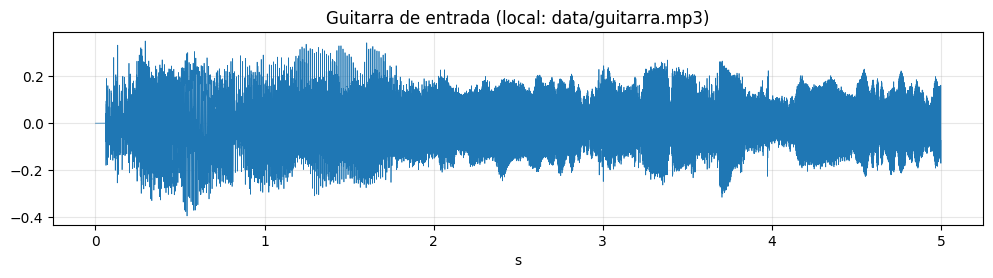

In [5]:
GUITAR_URL = "https://raw.githubusercontent.com/k0ngan/audio/main/guitarra.mp3"
SECONDS = 5.0

def _load_any(path, seconds):
    import librosa
    y, _ = librosa.load(path, sr=SR, mono=True)
    return ensure_mono_float(y)[:int(seconds * SR)]

def load_guitar(seconds=SECONDS):
    # 1) subir en Colab
    if IN_COLAB:
        try:
            from google.colab import files
            print("Sube tu guitarra (.wav/.mp3); o pulsa Cancelar para usar la de ejemplo.")
            up = files.upload()
            if up:
                return _load_any(list(up.keys())[0], seconds), "subida"
        except Exception as e:
            print("  (sin upload:", str(e)[:60], ")")
    # 2) copia local / descarga
    for p in ("guitarra.mp3", "data/guitarra.mp3"):
        if os.path.exists(p):
            return _load_any(p, seconds), "local: " + p
    try:
        urllib.request.urlretrieve(GUITAR_URL, "guitarra.mp3")
        return _load_any("guitarra.mp3", seconds), "GitHub"
    except Exception as e:
        print("  (sin red:", str(e)[:60], "-> guitarra sintética)")
    # 3) respaldo sintético: arpegio
    t = np.arange(int(seconds * SR)) / SR
    notes = [196, 247, 294, 392, 294, 247]
    x = np.zeros_like(t)
    seg = len(t) // len(notes)
    for i, f in enumerate(notes):
        s = i * seg
        x[s:s + seg] += np.sin(2 * np.pi * f * t[s:s + seg]) * np.hanning(seg)
    return normalize_audio(x), "sintética"

guitar, src = load_guitar()
print("Guitarra (%s): %.2f s" % (src, len(guitar) / SR))
plt.figure(figsize=(12, 2.5)); plt.plot(np.arange(len(guitar)) / SR, guitar, lw=0.5)
plt.title("Guitarra de entrada (%s)" % src); plt.xlabel("s"); plt.grid(alpha=0.3); plt.show()
display(Audio(guitar, rate=SR))


## 4. La voz
El cuaderno trae **incluida una voz real de Vocaloid 4** (CyberDiva, voz femenina cantada — uso académico, declarado), así que suena a voz de verdad sin subir nada. Si quieres, puedes subir tu propia muestra (`.wav`, un "aaah" sostenido); y si todo falla, hay una vocal sintética de respaldo.

In [6]:
VOICE_B64 = "..."

Voz (voz incluida (CyberDiva V4)): grano 400 ms, f0 base = 302 Hz


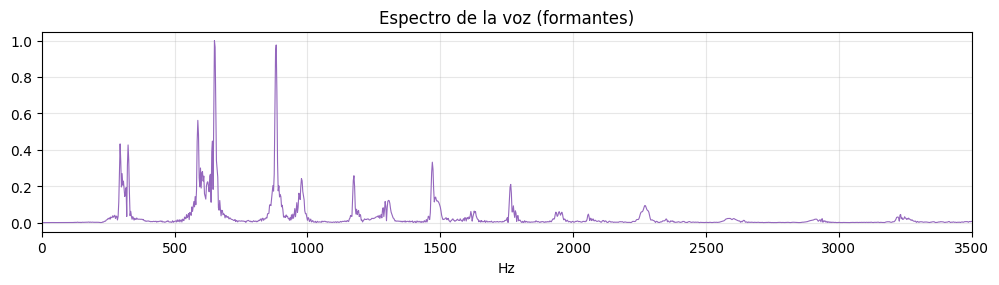

In [7]:
import base64, io
def load_voice():
    # 1) subir en Colab (override manual)
    if IN_COLAB:
        try:
            from google.colab import files
            print("Sube tu voz (.wav) o pulsa Cancelar para usar la voz incluida (CyberDiva V4).")
            up = files.upload()
            if up:
                import librosa
                y, _ = librosa.load(list(up.keys())[0], sr=SR, mono=True)
                return ensure_mono_float(y), "muestra subida"
        except Exception as e:
            print("  (sin upload:", str(e)[:60], ")")
    # 2) voz real incluida (embebida) o copia local
    if VOICE_B64:
        try:
            import soundfile as sf
            y, _ = sf.read(io.BytesIO(base64.b64decode(VOICE_B64)))
            return ensure_mono_float(y), "voz incluida (CyberDiva V4)"
        except Exception as e:
            print("  (voz embebida no disponible:", str(e)[:60], ")")
    for p in ("voces/miku_voice.wav", "miku_voice.wav"):
        if os.path.exists(p):
            import librosa
            y, _ = librosa.load(p, sr=SR, mono=True)
            return ensure_mono_float(y), "local: " + p
    # 3) respaldo sintético
    return synth_vowel(200.0, "a", dur=0.6, seed=2026), "vocal sintética /a/"

voice_raw, vsrc = load_voice()
voice_grain, voice_f0 = prep_voice_grain(voice_raw, SR)
print("Voz (%s): grano %.0f ms, f0 base = %.0f Hz" % (vsrc, 1000 * len(voice_grain) / SR, voice_f0))
f, mag = compute_rfft(voice_grain)
plt.figure(figsize=(12, 2.6)); plt.plot(f, mag / (mag.max() + 1e-9), lw=0.8, color="tab:purple")
plt.xlim(0, 3500); plt.title("Espectro de la voz (formantes)"); plt.xlabel("Hz"); plt.grid(alpha=0.3); plt.show()
display(Audio(voice_grain, rate=SR))


## 5. Detección de notas (pYIN, monofónico)
Estimamos el contorno de f0 y los tramos sonoros, y los agrupamos en notas.

Notas detectadas: 13


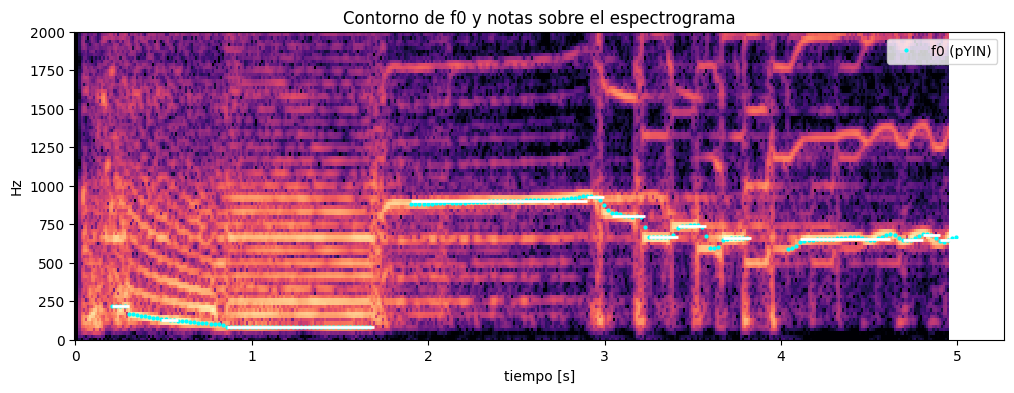

In [8]:
times, f0, voiced = track_f0_pyin(guitar, SR)
notes = segment_notes(times, f0, voiced)
print("Notas detectadas:", len(notes))

# espectrograma + contorno de f0
X = stft(guitar, n_fft=1024, hop=256)
S = 20 * np.log10(np.abs(X).T + 1e-6)
ff = np.fft.rfftfreq(1024, 1.0 / SR); tt = np.arange(X.shape[0]) * 256 / SR
m = ff <= 2000
plt.figure(figsize=(12, 4))
plt.pcolormesh(tt, ff[m], S[m], shading="auto", cmap="magma", vmin=S.max() - 70, vmax=S.max())
plt.plot(times, f0, ".", ms=4, color="cyan", label="f0 (pYIN)")
for (a, b, c) in notes:
    plt.hlines(c, a, b, color="white", lw=2)
plt.ylim(0, 2000); plt.title("Contorno de f0 y notas sobre el espectrograma")
plt.xlabel("tiempo [s]"); plt.ylabel("Hz"); plt.legend(loc="upper right"); plt.show()


## 6. Síntesis: 3 modos (robótico vs limpio)
- **resample** — afinado por remuestreo (corre formantes): suena robótico, **como el pedal**.
- **pv** — phase vocoder.
- **pv_formant** — phase vocoder con formantes: mantiene el timbre, **mejor que el pedal**.
Escucha el A/B.

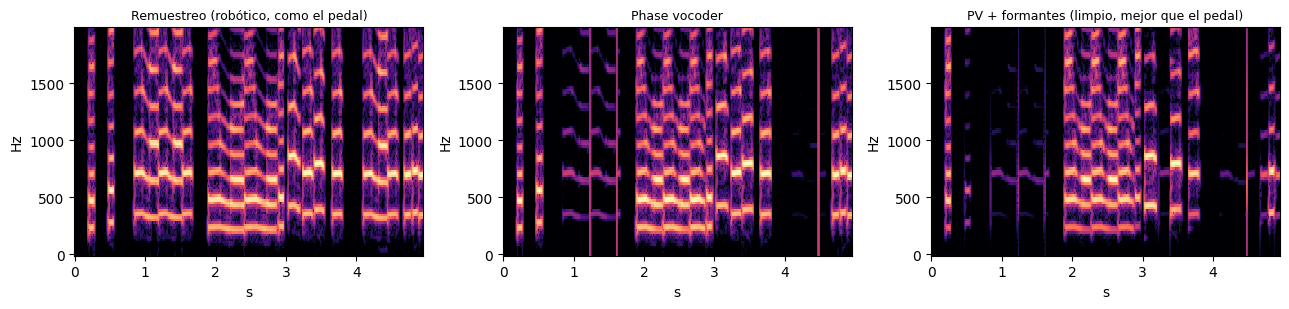

Remuestreo (robótico, como el pedal)


Phase vocoder


PV + formantes (limpio, mejor que el pedal)


In [9]:
voices = {}
for method in ["resample", "pv", "pv_formant"]:
    voices[method] = miku_stomp(notes, SR, voice_grain, voice_f0, len(guitar), method=method)

labels = {"resample": "Remuestreo (robótico, como el pedal)",
          "pv": "Phase vocoder",
          "pv_formant": "PV + formantes (limpio, mejor que el pedal)"}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for a, mth in zip(ax, voices):
    Xv = stft(voices[mth], n_fft=1024, hop=256)
    Sv = 20 * np.log10(np.abs(Xv).T + 1e-6)
    a.pcolormesh(np.arange(Xv.shape[0]) * 256 / SR, ff[m], Sv[m], shading="auto",
                 cmap="magma", vmin=Sv.max() - 70, vmax=Sv.max())
    a.set_title(labels[mth], fontsize=9); a.set_xlabel("s"); a.set_ylabel("Hz")
plt.tight_layout(); plt.show()
for mth in voices:
    print(labels[mth]); display(Audio(normalize_audio(voices[mth]), rate=SR))


## 7. Perilla MIX y salida final
Mezcla la voz con la guitarra seca (como el pedal) y descarga el resultado.

Guardado: miku_stomp_salida.wav


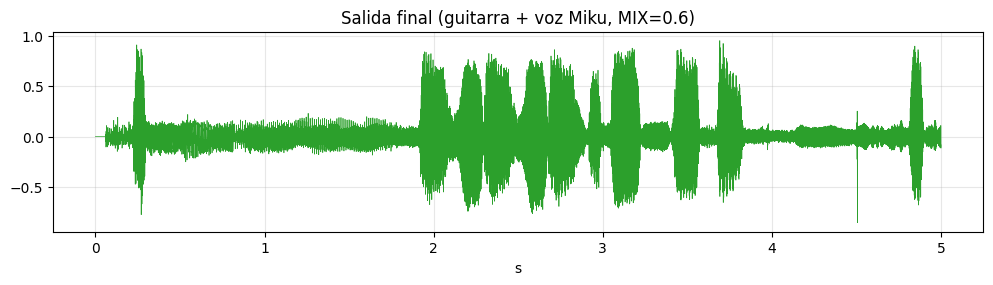

In [10]:
MIX = 0.6   # 0 = solo guitarra, 1 = solo voz
final = mix_over(guitar, voices["pv_formant"], mix=MIX)

import soundfile as sf
out_name = "miku_stomp_salida.wav"
sf.write(out_name, normalize_audio(final), SR)
print("Guardado:", out_name)
plt.figure(figsize=(12, 2.6)); plt.plot(np.arange(len(final)) / SR, final, lw=0.5, color="tab:green")
plt.title("Salida final (guitarra + voz Miku, MIX=%.1f)" % MIX); plt.xlabel("s"); plt.grid(alpha=0.3); plt.show()
display(Audio(final, rate=SR))
if IN_COLAB:
    try:
        from google.colab import files
        files.download(out_name)
    except Exception as e:
        print("(descarga manual desde el panel de archivos)", str(e)[:60])


## 8. Discusión

- **Por qué supera al pedal:** el Korg Miku Stomp es monofónico y al transponer **corre los
  formantes**; nuestro modo `pv_formant` **mantiene el timbre** (formantes fijos) y afina con pYIN,
  más preciso que el seguimiento analógico del pedal.
- **Límites:** es **monofónico** (una nota a la vez) y funciona por **lotes** (graba → procesa →
  descarga), no en tiempo real como el pedal físico. En notas muy agudas el plegado de octava mantiene
  la voz cantable, pero saltos extremos degradan el phase vocoder (igual que en el proyecto del
  artículo).
- **Trabajo futuro (fuera del eje DSP del ramo):** polifonía con *Basic Pitch*, clonación de timbre
  con *RVC*, o síntesis tipo *OpenUTAU*; y llevarlo a **tiempo real** como plugin (JUCE / Reaper).
- **Reutilización:** el núcleo DSP (`vocoder.py`) proviene del proyecto del phase vocoder; lo nuevo
  aquí es el pipeline del pedal (`stomp.py`: pYIN, segmentación de notas y síntesis con tiling).
